## Data Exploratory Analysis (EDA)
### Visualization of correlation & distributions of weather variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install --upgrade pyarrow
import pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
sns.set_theme(style="whitegrid")
%matplotlib inline

In [7]:
# Load data
df = pd.read_parquet("../data/processed/features_data.parquet")

In [8]:
weather_cols = ['temp_acum_1m', 'pres_prom_1m', 'viento_prom_1m', 'hum_prom_1m']

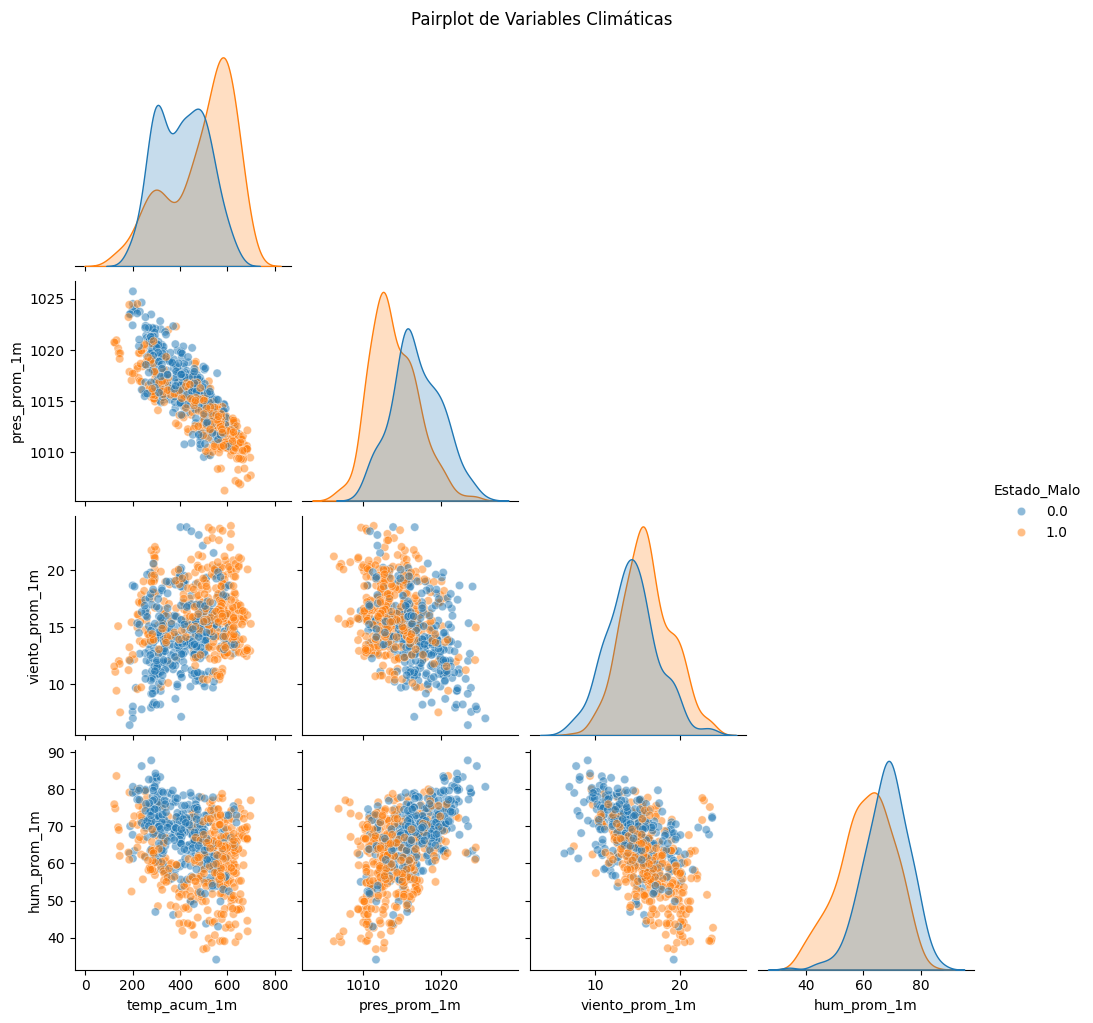

In [12]:
# ==========================================
# 1. Pairplot (Correlation & Distribution)
# ==========================================

sns.pairplot(df[weather_cols+["Estado_Malo"]], corner=True, hue="Estado_Malo",diag_kind="kde", plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot de Variables Climáticas", y=1.02)
plt.show()

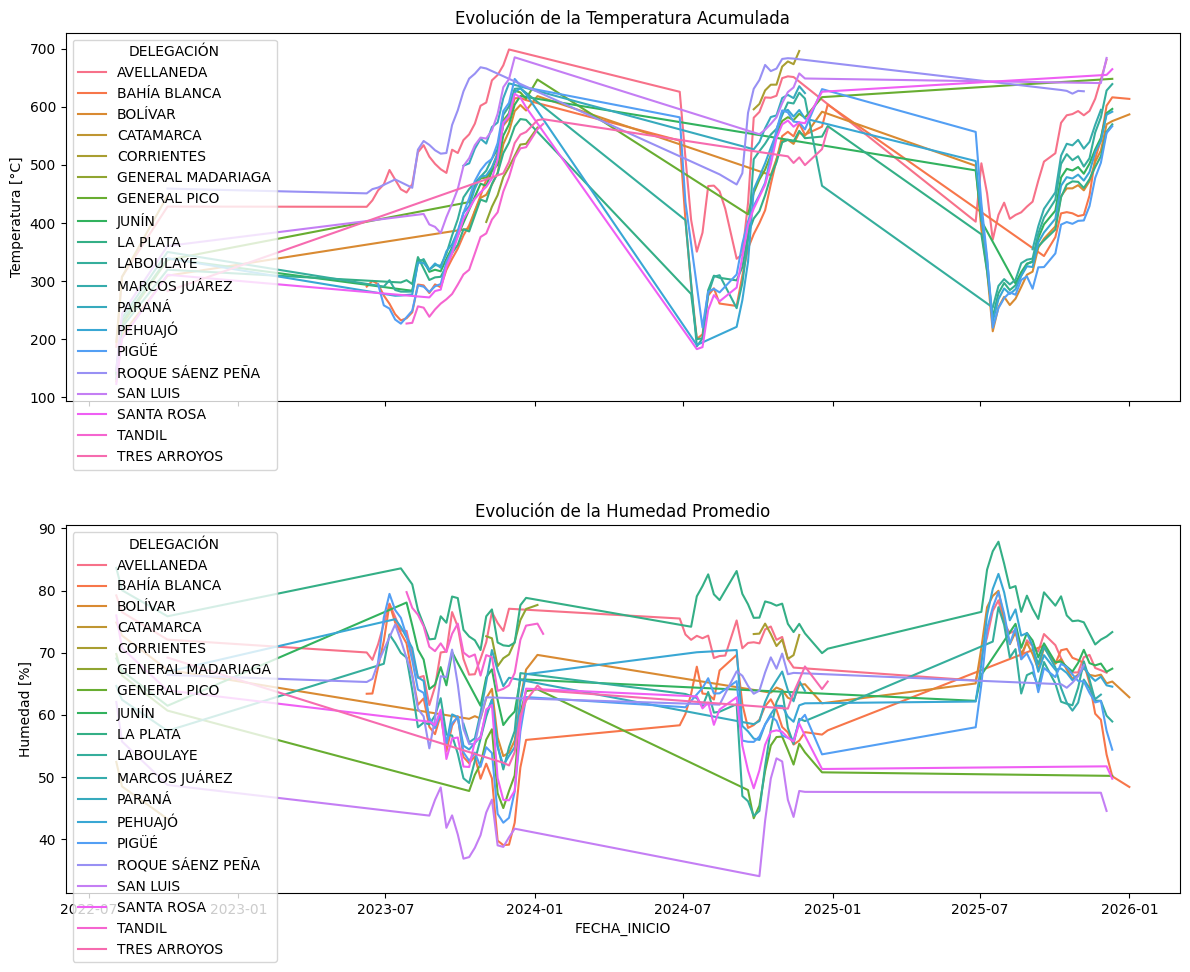

In [13]:

# ==========================================
# 2. Time series
# # ==========================================

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

sns.lineplot(data=df, x='FECHA_INICIO', y='temp_acum_1m', hue='DELEGACIÓN', ax=axes[0])
axes[0].set_title("Evolución de la Temperatura Acumulada")
axes[0].set_ylabel("Temperatura [°C]")

sns.lineplot(data=df, x='FECHA_INICIO', y='hum_prom_1m', hue='DELEGACIÓN', ax=axes[1])
axes[1].set_title("Evolución de la Humedad Promedio")
axes[1].set_ylabel("Humedad [%]")

plt.tight_layout()
plt.show()


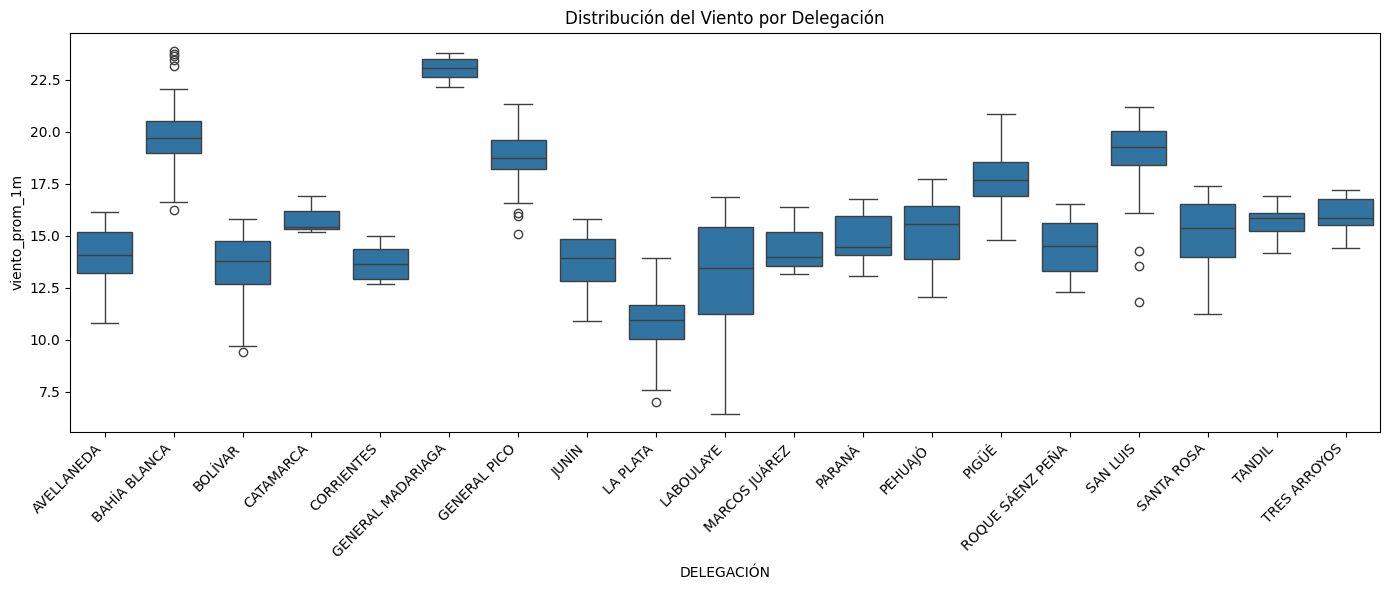

In [14]:

# ==========================================
# 3. Boxplots (Outliers por Delegación)
# ==========================================
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='DELEGACIÓN', y='viento_prom_1m')
plt.xticks(rotation=45, ha='right')
plt.title("Distribución del Viento por Delegación")
plt.tight_layout()
plt.show()